# Loading sweep results (Cell Type classification).

## Preparing the notebook.

### Flags for autoreloading.

In [1]:
AUTORELOAD = True
IS_EXT_LOADED = False

### Auto-reloading the notebook.

In [2]:
if AUTORELOAD:
    if not IS_EXT_LOADED:
        %load_ext autoreload
        IS_EXT_LOADED = True
    assert IS_EXT_LOADED
    %autoreload 2

### Importing the libraries.

In [25]:
from collections import defaultdict
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import softmax
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import LabelEncoder, label_binarize
import torch
from tqdm import tqdm
import wandb
import yaml

from sc_exp_design.models import TargetPredictionModel

### Constants.

In [130]:
# data settings
CELL_STATE_REP = "X_channel_standardized+X_scatter_standardized"

# wandb settings
ENTITY = "haematopoiesis-cambridge"
PROJECT = f"sweep_classifier_{CELL_STATE_REP}"

# defining cell types of interest
CELL_TYPES_OF_INTEREST = [
    "HSCs", "Pro-B", "Early_Pro-B",
    "MgkPro", "GMP-Neutro/CD16-Mono", "CD14-Mono", "DCs-CD14"
]


### Utility Functions.

In [84]:
def evaluate_classifier(
    results_dict
):
    Y_pred_probs = results_dict["pred_probs"]
    Y_pred_label = results_dict["pred_cell_type"]
    Y_pred_id = results_dict["pred_int_label"]
    Y_labels = results_dict["gt_cell_type"]
    Y = results_dict["gt_int_label"]
    Y_pred_label = results_dict["pred_cell_type"]
    le_cell_type = results_dict["le"]
    cm = confusion_matrix(
        Y_labels,
        Y_pred_label,
        labels=le_cell_type.classes_,
    )
    accuracy = accuracy_score(Y, Y_pred_id)
    precision = precision_score(Y, Y_pred_id, average="weighted")
    recall = recall_score(Y, Y_pred_id, average="weighted")
    f1 = f1_score(Y, Y_pred_id, average="weighted")
    report = classification_report(Y, Y_pred_id, target_names=le_cell_type.classes_, output_dict=True)
    y_true_bin = label_binarize(
        [np.where(le_cell_type.classes_ == c)[0][0] for c in Y_labels], classes=range(len(le_cell_type.classes_))
    )
    classes_roc_auc = {}
    classes_fpr = {}
    classes_tpr = {}
    for i, class_label in enumerate(le_cell_type.classes_):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], Y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        classes_roc_auc[class_label] = roc_auc
        classes_fpr[class_label] = fpr
        classes_tpr[class_label] = tpr
        # report[class_label]["tpr"] = tpr
        # report[class_label]["fpr"] = fpr
        report[class_label]["roc_auc"] = roc_auc
    macro_roc_auc = roc_auc_score(y_true_bin, Y_pred_probs, average="macro")
    micro_roc_auc = roc_auc_score(y_true_bin, Y_pred_probs, average="micro")
    return {
        "cm": cm,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "report": report,
        "classes_roc_auc": classes_roc_auc,
        "classes_tpr": classes_tpr,
        "classes_fpr": classes_fpr,
        "micro_roc_auc": micro_roc_auc,
        "macro_roc_auc": macro_roc_auc,
        "use_cls_weights": results_dict["use_cls_weights"]
    }


def make_combined_eval_dataframe(eval_dict):
    rows = []
    for key, metrics in eval_dict.items():
        column, seed, split, model_name = key
        # global metrics
        rows.append({
            "column": column,
            "seed": seed,
            "split": split,
            "model": model_name,
            "class": "GLOBAL",
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "macro_roc_auc": metrics["macro_roc_auc"],
            "micro_roc_auc": metrics["micro_roc_auc"],
            "use_cls_weights": metrics["use_cls_weights"]
        })
        # per-class metrics
        for cls, cls_metrics in metrics["report"].items():
            if cls in ["accuracy", "macro avg", "weighted avg"]:
                continue
            rows.append({
                "column": column,
                "seed": seed,
                "split": split,
                "model": model_name,
                "class": cls,
                "precision": cls_metrics["precision"],
                "recall": cls_metrics["recall"],
                "f1": cls_metrics["f1-score"],
                "support": cls_metrics["support"],
                "roc_auc": cls_metrics["roc_auc"],
                "use_cls_weights": metrics["use_cls_weights"]    
            })
    return pd.DataFrame(rows)


def display_cm(cm, title, le_cell_type):
    fig, axes = plt.subplots(figsize=(7, 7))
    val_cmd = ConfusionMatrixDisplay(
        cm,
        display_labels=le_cell_type.classes_,
    )
    val_cmd.plot(ax=axes)
    axes.tick_params("x", rotation=90, size=8)
    axes.set_title(f"Confusion matrix {title}")
    return fig, axes


## Prepare Wandb.

### Set-up the API and retrieve runs.

In [63]:
api = wandb.Api()
runs = api.runs(f"{ENTITY}/{PROJECT}")
print(len(runs))

300


### Retrieving finished runs.

In [64]:
finished_runs = []
for run in runs:
    if run.state == "finished":
        finished_runs.append(run)
print(len(finished_runs))

300


### Retrieving history of runs.

In [67]:
summary_list = []
for run in finished_runs:
    data = run.summary
    splits_config = run.config["splits"].copy()
    flat_data = {
        **data,
        **data['_wandb'],
        **splits_config.pop("kwargs"),
        **splits_config,
        "use_class_weights": run.config["training"]["use_class_weights"],
        **{
            "dump_path": os.path.join(run.config["paths"]["dump_dir"], f"{run.name}_TargetPredictionModel.pkl")
        }
    }
    df = pd.DataFrame([flat_data])
    df.index = [run.name]
    summary_list.append(df)
summary_df = pd.concat(summary_list, axis=0)
summary_df.head()

,_runtime,_step,_timestamp,_wandb,cell_type_accuracy,cell_type_macro_f1_score,cell_type_macro_precision,cell_type_macro_recall,cell_type_macro_roc_auc,cell_type_micro_f1_score,...,train_step,runtime,K,test_size,random_state,split_to_retieve,mode,obs_col,use_class_weights,dump_path
drawn-water-1,80.398329,549,1.762975e+09,{'runtime': 80},0.884567,0.885151,0.890336,0.880436,0.990220,0.884567,...,49999,80,3,0.3,20913,2,shuffle,cell_type,False,/lustre/groups/ml01/workspace/lorenzo.consoli/...
fearless-surf-2,81.830869,549,1.762975e+09,{'runtime': 81},0.884067,0.881120,0.882734,0.880095,0.995783,0.884067,...,49999,81,3,0.3,20913,2,shuffle,cell_type,False,/lustre/groups/ml01/workspace/lorenzo.consoli/...
happy-sea-3,131.709088,549,1.762975e+09,{'runtime': 131},0.862200,0.831809,0.836082,0.843421,0.986342,0.862200,...,49999,131,3,0.3,42,2,shuffle,cell_type,True,/lustre/groups/ml01/workspace/lorenzo.consoli/...
fine-darkness-4,82.592282,549,1.762975e+09,{'runtime': 82},0.865500,0.869876,0.851707,0.891423,0.990846,0.865500,...,49999,82,3,0.3,20913,0,shuffle,cell_type,True,/lustre/groups/ml01/workspace/lorenzo.consoli/...
wobbly-water-5,92.972781,549,1.762975e+09,{'runtime': 92},0.883467,0.880296,0.881553,0.879370,0.995934,0.883467,...,49999,92,3,0.3,12834,2,shuffle,cell_type,False,/lustre/groups/ml01/workspace/lorenzo.consoli/...


### Retrieving only columns of interest.

In [69]:
results_df = summary_df.loc[:, [
    "obs_col",
    "dump_path",
    "mode",
    "random_state",
    "split_to_retieve",
    "use_class_weights",
    *[
        col for col in summary_df.columns if col.startswith("cell_type")
    ]
]]
results_df.head()

,obs_col,dump_path,mode,random_state,split_to_retieve,use_class_weights,cell_type_accuracy,cell_type_macro_f1_score,cell_type_macro_precision,cell_type_macro_recall,cell_type_macro_roc_auc,cell_type_micro_f1_score,cell_type_micro_precision,cell_type_micro_recall,cell_type_micro_roc_auc,cell_type_pert_posterior_loss,cell_type_weighted_f1_score,cell_type_weighted_precision,cell_type_weighted_recall
drawn-water-1,cell_type,/lustre/groups/ml01/workspace/lorenzo.consoli/...,shuffle,20913,2,False,0.884567,0.885151,0.890336,0.880436,0.990220,0.884567,0.884567,0.884567,0.994581,0.000003,0.884522,0.884569,0.884567
fearless-surf-2,cell_type,/lustre/groups/ml01/workspace/lorenzo.consoli/...,shuffle,20913,2,False,0.884067,0.881120,0.882734,0.880095,0.995783,0.884067,0.884067,0.884067,0.996876,0.162700,0.883999,0.884156,0.884067
happy-sea-3,cell_type,/lustre/groups/ml01/workspace/lorenzo.consoli/...,shuffle,42,2,True,0.862200,0.831809,0.836082,0.843421,0.986342,0.862200,0.862200,0.862200,0.990065,0.146288,0.863408,0.866685,0.862200
fine-darkness-4,cell_type,/lustre/groups/ml01/workspace/lorenzo.consoli/...,shuffle,20913,0,True,0.865500,0.869876,0.851707,0.891423,0.990846,0.865500,0.865500,0.865500,0.993403,0.065354,0.866116,0.868262,0.865500
wobbly-water-5,cell_type,/lustre/groups/ml01/workspace/lorenzo.consoli/...,shuffle,12834,2,False,0.883467,0.880296,0.881553,0.879370,0.995934,0.883467,0.883467,0.883467,0.996744,0.000288,0.883289,0.883256,0.883467


### Grouping results by ood column and split.

In [70]:
split2results = {}
for group_id, group_idxs in results_df.groupby(by=["obs_col", "random_state", "split_to_retieve"]).groups.items():
    print(f"{group_id} -> {len(group_idxs)}")
    split2results[group_id] = results_df.loc[group_idxs]
print(len(split2results), list(split2results.keys()))

('cell_type', 42, 0) -> 11
('cell_type', 42, 1) -> 26
('cell_type', 42, 2) -> 13
('cell_type', 12834, 0) -> 26
('cell_type', 12834, 1) -> 22
('cell_type', 12834, 2) -> 23
('cell_type', 20913, 0) -> 16
('cell_type', 20913, 1) -> 12
('cell_type', 20913, 2) -> 22
('cell_type', 191874, 0) -> 26
('cell_type', 191874, 1) -> 22
('cell_type', 191874, 2) -> 18
('cell_type', 2481024, 0) -> 24
('cell_type', 2481024, 1) -> 15
('cell_type', 2481024, 2) -> 24
15 [('cell_type', 42, 0), ('cell_type', 42, 1), ('cell_type', 42, 2), ('cell_type', 12834, 0), ('cell_type', 12834, 1), ('cell_type', 12834, 2), ('cell_type', 20913, 0), ('cell_type', 20913, 1), ('cell_type', 20913, 2), ('cell_type', 191874, 0), ('cell_type', 191874, 1), ('cell_type', 191874, 2), ('cell_type', 2481024, 0), ('cell_type', 2481024, 1), ('cell_type', 2481024, 2)]


### 

### Scatter plot of metrics against each other.

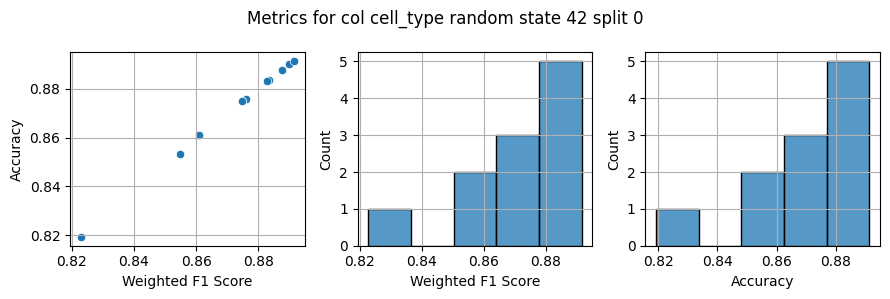

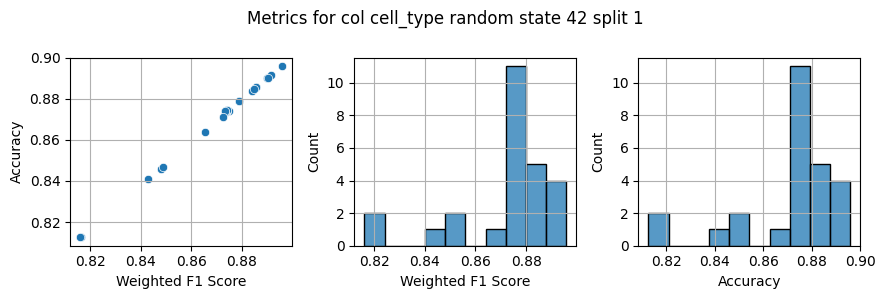

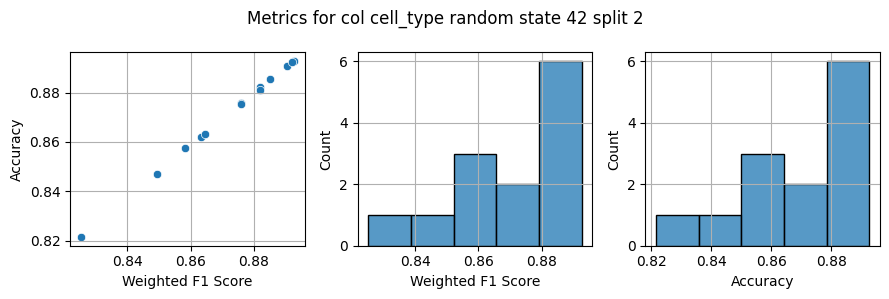

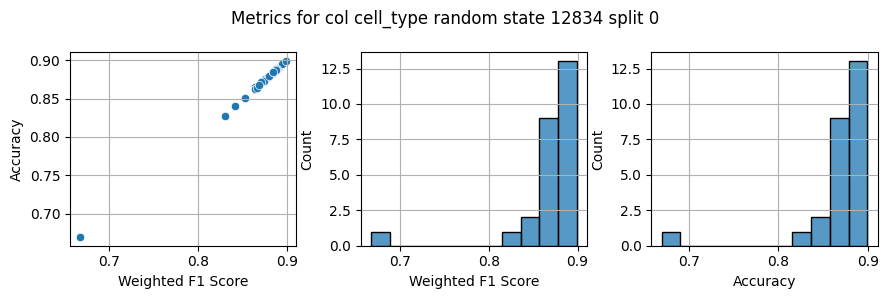

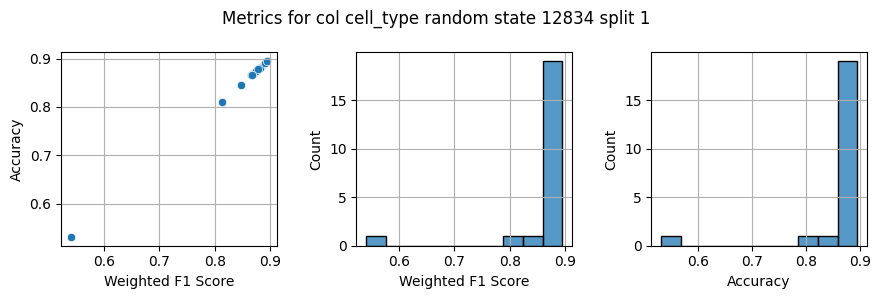

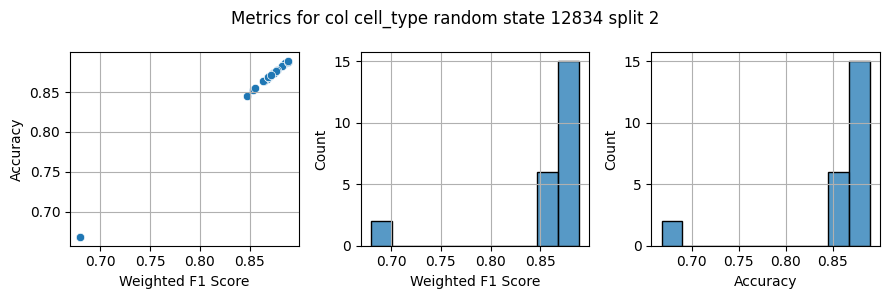

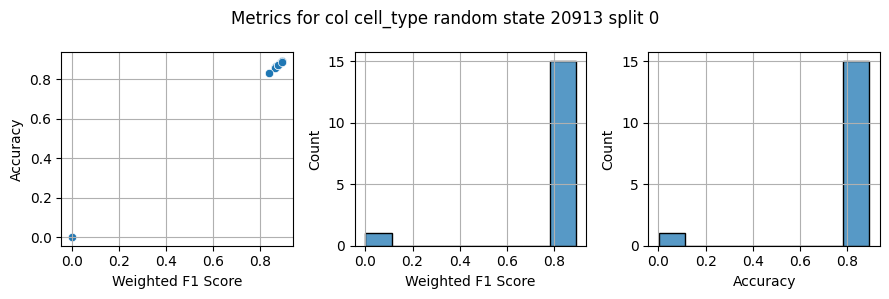

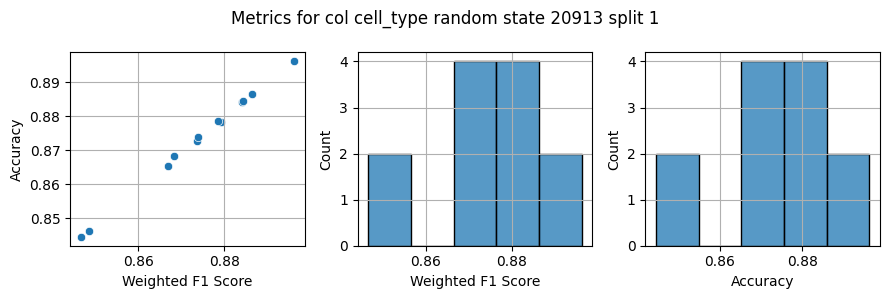

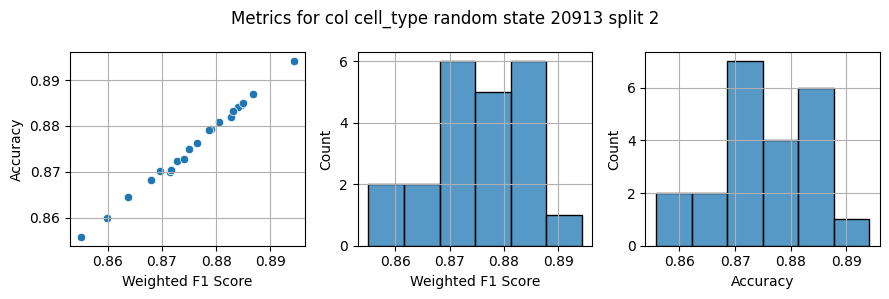

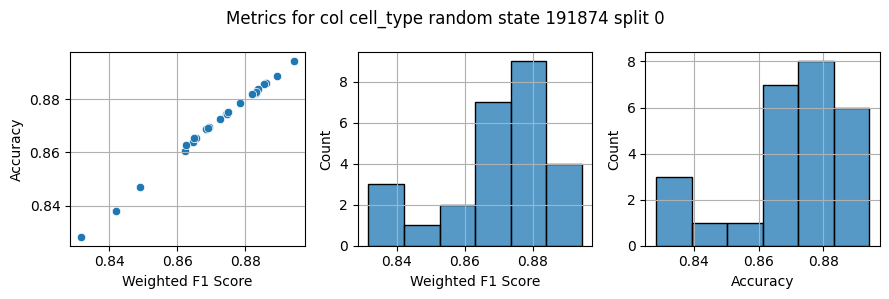

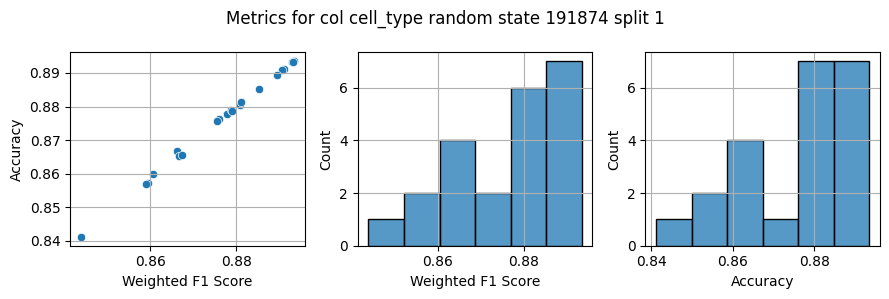

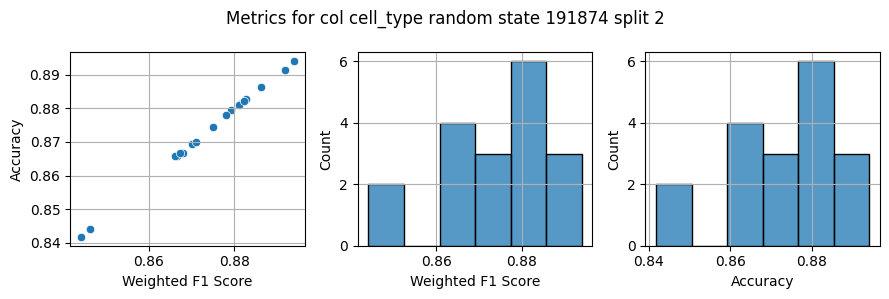

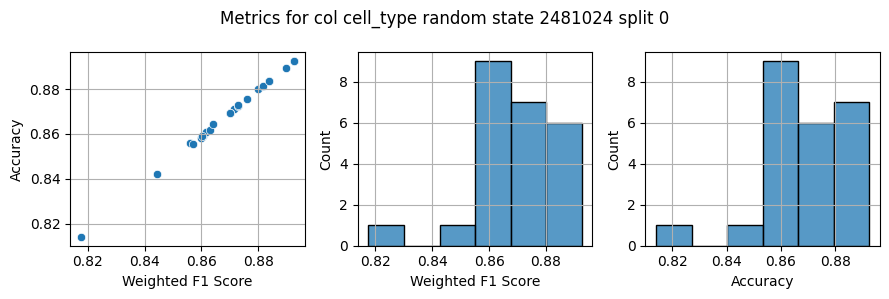

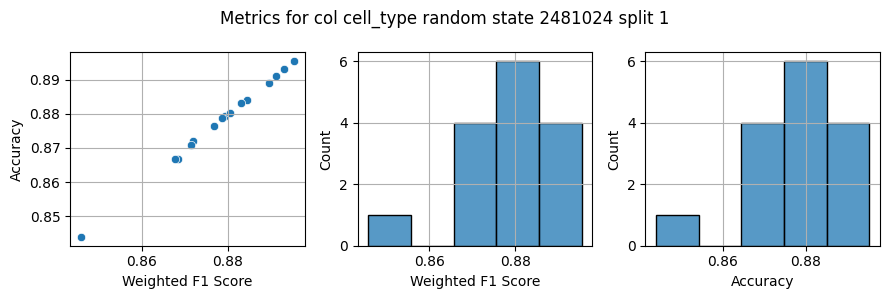

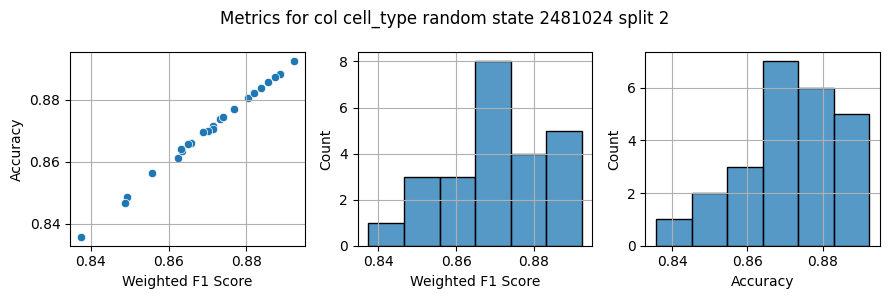

In [71]:
use_log_e_dist = True
for group_id, group_df in split2results.items():
    fig, ax = plt.subplots(1, 3, figsize=(9, 3))
    fig.suptitle(f"Metrics for col {group_id[0]} random state {group_id[1]} split {group_id[2]}")
    sns.scatterplot(group_df, x="cell_type_weighted_f1_score", y="cell_type_accuracy", ax=ax[0])
    ax[0].set_xlabel("Weighted F1 Score")
    ax[0].set_ylabel("Accuracy")
    ax[0].grid(True)
    # hist e dist
    sns.histplot(group_df, x="cell_type_weighted_f1_score", ax=ax[1])
    ax[1].set_xlabel("Weighted F1 Score")
    ax[1].grid(True)
    # hist r2
    sns.histplot(group_df, x="cell_type_accuracy", ax=ax[2])
    ax[2].set_xlabel("Accuracy")
    ax[2].grid(True)
    fig.tight_layout()
    fig.show()

### Retrieving best run id and metrics for each run.

In [74]:
select_best_result = False
criterion_id = "cell_type_weighted_f1_score"
if select_best_result:
    index = []
    ood2bestcfg = defaultdict(list)
    for group_id, group_df in split2results.items():
        best_run_idx = np.argmax(group_df[criterion_id].values)
        best_model_path = group_df.iloc[best_run_idx]["dump_path"]
        best_criterion = group_df.iloc[best_run_idx][criterion_id]
        use_class_weights = group_df.iloc[best_run_idx]["use_class_weights"]
        best_run_name = group_df.index[best_run_idx]
        ood2bestcfg["model_path"].append(best_model_path)
        ood2bestcfg["run_name"].append(best_run_name)
        ood2bestcfg["criterion"].append(best_criterion)
        ood2bestcfg["use_class_weights"].append(use_class_weights)
        index.append(group_id + (best_run_name, ))
    best_results_df = pd.DataFrame(ood2bestcfg)
    best_results_df
    best_results_df.index = pd.MultiIndex.from_tuples(index, names=["ood_col", "random_state", "split_id", "run_name"])
else:
    index = []
    ood2bestcfg = defaultdict(list)
    for group_id, group_df in split2results.items():
        for idx in range(len(group_df)):
            model_path = group_df.iloc[idx]["dump_path"]
            criterion = group_df.iloc[idx][criterion_id]
            use_class_weights = group_df.iloc[idx]["use_class_weights"]    
            run_name = group_df.index[idx]
            ood2bestcfg["model_path"].append(model_path)
            ood2bestcfg["run_name"].append(run_name)
            ood2bestcfg["criterion"].append(criterion)
            ood2bestcfg["use_class_weights"].append(use_class_weights)
            index.append(group_id + (run_name, ))
    best_results_df = pd.DataFrame(ood2bestcfg)
    best_results_df.index = pd.MultiIndex.from_tuples(index, names=["ood_col", "random_state", "split_id", "run_name"])
best_results_df

model_path  \
ood_col   random_state split_id run_name                                                                   
cell_type 42           0        vivid-hill-21          /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                colorful-butterfly-38  /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                proud-wildflower-47    /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                glorious-cloud-55      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                lucky-planet-111       /lustre/groups/ml01/workspace/lorenzo.consoli/...   
...                                                                                                  ...   
          2481024      2        cerulean-surf-198      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                tough-shape-200        /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                vocal-puddle-214       /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                bumbling-tree-224      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                confused-capybara-267  /lustre/groups/ml01/workspace/lorenzo.consoli/...   

                                                                    run_name  \
ood_col   random_state split_id run_name                                       
cell_type 42           0        vivid-hill-21                  vivid-hill-21   
                                colorful-butterfly-38  colorful-butterfly-38   
                                proud-wildflower-47      proud-wildflower-47   
                                glorious-cloud-55          glorious-cloud-55   
                                lucky-planet-111            lucky-planet-111   
...                                                                      ...   
          2481024      2        cerulean-surf-198          cerulean-surf-198   
                                tough-shape-200              tough-shape-200   
                                vocal-puddle-214            vocal-puddle-214   
                                bumbling-tree-224          bumbling-tree-224   
                                confused-capybara-267  confused-capybara-267   

                                                       criterion  \
ood_col   random_state split_id run_name                           
cell_type 42           0        vivid-hill-21           0.889790   
                                colorful-butterfly-38   0.883537   
                                proud-wildflower-47     0.891555   
                                glorious-cloud-55       0.882985   
                                lucky-planet-111        0.876053   
...                                                          ...   
          2481024      2        cerulean-surf-198       0.855718   
                                tough-shape-200         0.864995   
                                vocal-puddle-214        0.876779   
                                bumbling-tree-224       0.863098   
                                confused-capybara-267   0.868989   

                                                       use_class_weights  
ood_col   random_state split_id run_name                                  
cell_type 42           0        vivid-hill-21                      False  
                                colorful-butterfly-38              False  
                                proud-wildflower-47                 True  
                                glorious-cloud-55                  False  
                                lucky-planet-111                   False  
...                                                                  ...  
          2481024      2        cerulean-surf-198                  False  
                                tough-shape-200                    False  
             

### Slicing for target value.

In [75]:
select_split = False
if select_split:
    # defining target splits
    ood_col = "cell_type"
    ood_random_state = 42
    ood_split = 0

    # defining masks
    col_mask = best_results_df.index.map(lambda e: e[0] == ood_col)
    random_state_mask = best_results_df.index.map(lambda e: e[1] == ood_random_state)
    split_mask = best_results_df.index.map(lambda e: e[2] == ood_split)
    mask = (col_mask & random_state_mask & split_mask)

    # slicing df
    tgt_res_df = best_results_df[mask]
else:
    tgt_res_df = best_results_df
tgt_res_df


model_path  \
ood_col   random_state split_id run_name                                                                   
cell_type 42           0        vivid-hill-21          /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                colorful-butterfly-38  /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                proud-wildflower-47    /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                glorious-cloud-55      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                lucky-planet-111       /lustre/groups/ml01/workspace/lorenzo.consoli/...   
...                                                                                                  ...   
          2481024      2        cerulean-surf-198      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                tough-shape-200        /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                vocal-puddle-214       /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                bumbling-tree-224      /lustre/groups/ml01/workspace/lorenzo.consoli/...   
                                confused-capybara-267  /lustre/groups/ml01/workspace/lorenzo.consoli/...   

                                                                    run_name  \
ood_col   random_state split_id run_name                                       
cell_type 42           0        vivid-hill-21                  vivid-hill-21   
                                colorful-butterfly-38  colorful-butterfly-38   
                                proud-wildflower-47      proud-wildflower-47   
                                glorious-cloud-55          glorious-cloud-55   
                                lucky-planet-111            lucky-planet-111   
...                                                                      ...   
          2481024      2        cerulean-surf-198          cerulean-surf-198   
                                tough-shape-200              tough-shape-200   
                                vocal-puddle-214            vocal-puddle-214   
                                bumbling-tree-224          bumbling-tree-224   
                                confused-capybara-267  confused-capybara-267   

                                                       criterion  \
ood_col   random_state split_id run_name                           
cell_type 42           0        vivid-hill-21           0.889790   
                                colorful-butterfly-38   0.883537   
                                proud-wildflower-47     0.891555   
                                glorious-cloud-55       0.882985   
                                lucky-planet-111        0.876053   
...                                                          ...   
          2481024      2        cerulean-surf-198       0.855718   
                                tough-shape-200         0.864995   
                                vocal-puddle-214        0.876779   
                                bumbling-tree-224       0.863098   
                                confused-capybara-267   0.868989   

                                                       use_class_weights  
ood_col   random_state split_id run_name                                  
cell_type 42           0        vivid-hill-21                      False  
                                colorful-butterfly-38              False  
                                proud-wildflower-47                 True  
                                glorious-cloud-55                  False  
                                lucky-planet-111                   False  
...                                                                  ...  
          2481024      2        cerulean-surf-198                  False  
                                tough-shape-200                    False  
             

## Predicting with the model.

### Grouping by OOD column loading best model per split.

In [77]:
ood2model = {}
pbar = tqdm(range(len(tgt_res_df)))
for row in tgt_res_df.iterrows():
    group_id, (path, run_name, criterion, use_class_weights) = row
    pbar.set_description(f"Loading model for {group_id} from {path}")
    pbar.update()
    ood2model[group_id] = TargetPredictionModel.load(path)


  0%|          | 0/300 [00:07<?, ?it/s]
Loading model for ('cell_type', 2481024, 2, 'confused-capybara-267') from /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-12_20-11-53/confused-capybara-267_TargetPredictionModel.pkl: 100%|██████████| 300/300 [01:45<00:00,  3.12it/s]     

### Predicting with model on its whole validation data.

In [83]:
ood2preds = {}
pbar = tqdm(range(len(ood2model)))
for split_id, model in ood2model.items():
    # progress bar
    pbar.set_description(f"Predicting with model for {split_id}")
    pbar.update()
    # forward pass on model
    val_data = model.validation_data
    state_data = torch.from_numpy(val_data.state_data).float().to(model.device)
    gt_int_label = model.validation_data.target_data["cell_type"]
    pred_logits = model.predict(state_data)["cell_type"].detach().cpu().numpy()
    # computing probabilities and label
    pred_probs = softmax(pred_logits, axis=-1)
    pred_int_label = pred_probs.argmax(-1)
    # label decoder
    le = LabelEncoder().fit(model.train_data.adata.obs["cell_type"])
    pred_cell_type = le.inverse_transform(pred_int_label)
    gt_cell_type = le.inverse_transform(gt_int_label)
    # storing results
    ood2preds[split_id] = {
        "pred_logits": pred_logits,
        "pred_probs": pred_probs,
        "pred_int_label": pred_int_label,
        "pred_cell_type": pred_cell_type,
        "gt_int_label": gt_int_label,
        "gt_cell_type": gt_cell_type,
        "le": le,
        "use_cls_weights": tgt_res_df.loc[split_id].use_class_weights.item()            
    }

Predicting with model for ('cell_type', 2481024, 2, 'confused-capybara-267'): 100%|██████████| 300/300 [01:00<00:00,  4.99it/s]
Predicting with model for ('cell_type', 42, 0, 'vivid-hill-21'):   0%|          | 0/300 [00:00<?, ?it/s]

Predicting with model for ('cell_type', 2481024, 2, 'confused-capybara-267'): 100%|█████████▉| 299/300 [00:03<00:00, 104.17it/s]  

Predicting with model for ('cell_type', 2481024, 2, 'confused-capybara-267'): 100%|██████████| 300/300 [00:15<00:00, 104.17it/s]

## Performance Metrics.

### Evaluating the predictions on the full validation data.

In [ ]:
# dictionary to store the results
split2metrics_dict = {}
pbar = tqdm(range(len(ood2preds)))
# iterating over the pre-computed predictions
for split_id, preds_dict in ood2preds.items():
    eval_results_dict = evaluate_classifier(preds_dict)
    split2metrics_dict[split_id] = eval_results_dict
    pbar.set_description(f"Eval Preds w/ {split_id}")
    pbar.update()
eval_results_df = make_combined_eval_dataframe(split2metrics_dict)


Predicting with model for ('cell_type', 2481024, 2, 'confused-capybara-267'): 100%|██████████| 300/300 [01:20<00:00,  3.74it/s] 
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarnin

### Plotting metrics by class.

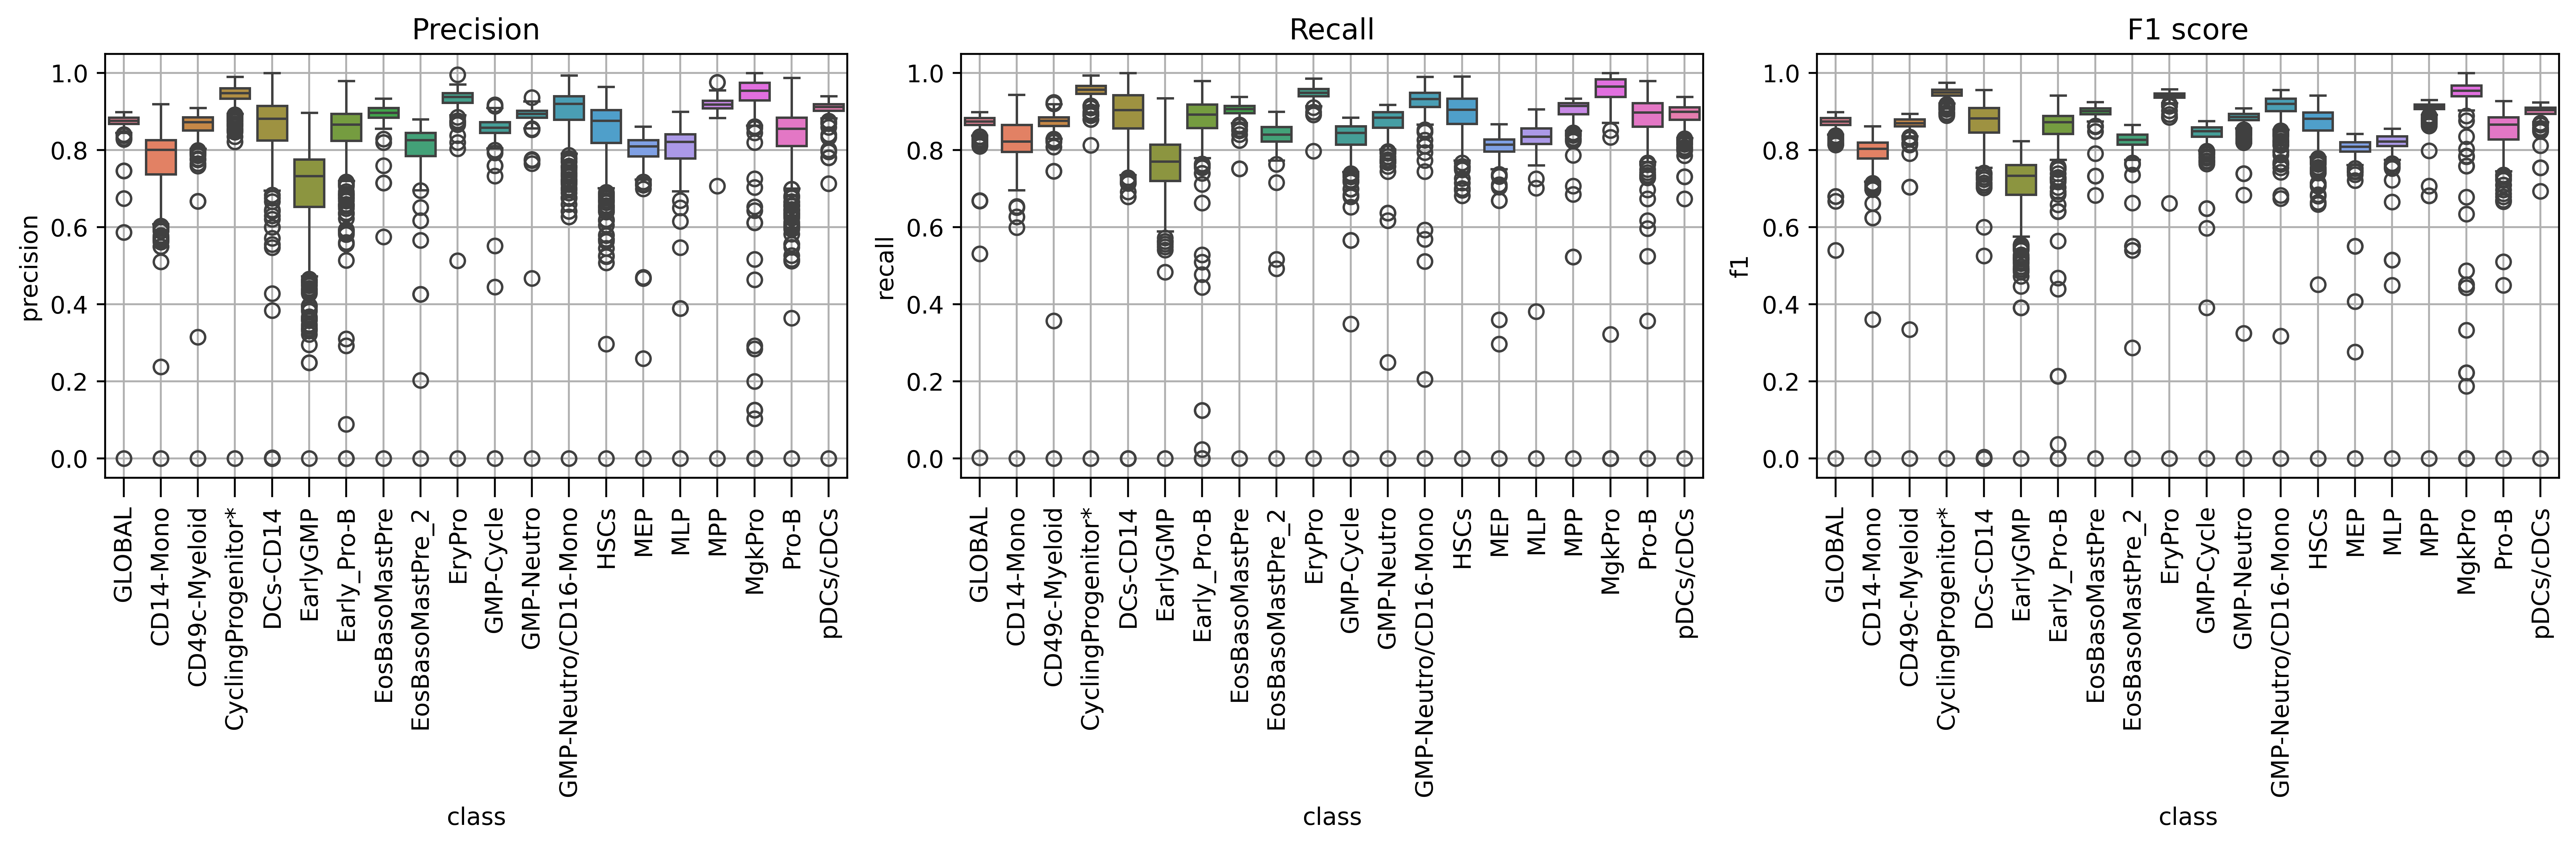

In [138]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), dpi=500)
sns.boxplot(eval_results_df, y="precision", x="class", ax=ax[0], hue="class"); ax[0].tick_params("x", rotation=90, size=8); ax[0].grid(1); ax[0].set_title("Precision")
sns.boxplot(eval_results_df, y="recall", x="class", ax=ax[1], hue="class"); ax[1].tick_params("x", rotation=90, size=8); ax[1].grid(1); ax[1].set_title("Recall")
sns.boxplot(eval_results_df, y="f1", x="class", ax=ax[2], hue="class"); ax[2].tick_params("x", rotation=90, size=8); ax[2].grid(1); ax[2].set_title("F1 score")
fig.tight_layout()
fig.show()

### Same plot but only for cell type of interest.

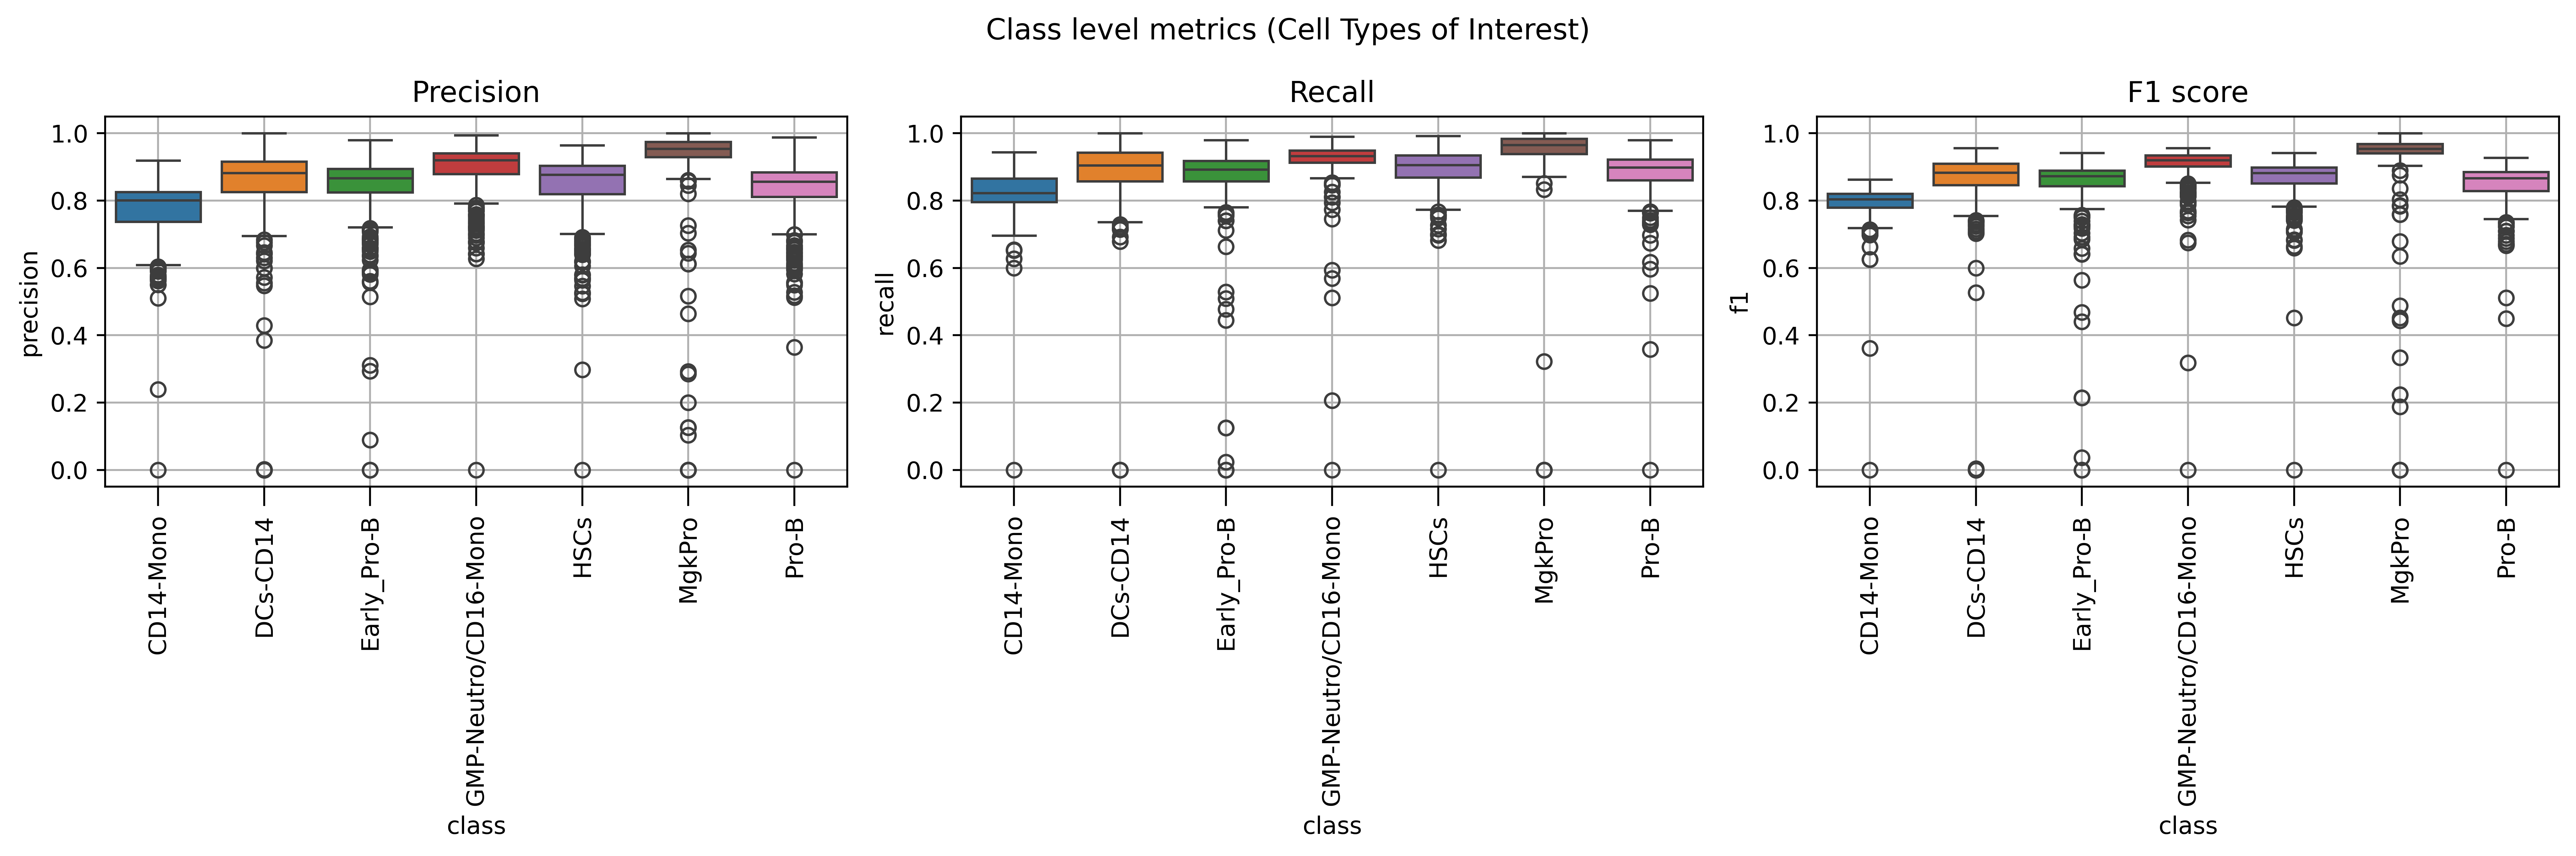

In [137]:
cell_types_of_interest_eval_results_df = eval_results_df[
    eval_results_df["class"].map(lambda e: e in CELL_TYPES_OF_INTEREST)
]
fig, ax = plt.subplots(1, 3, figsize=(15, 5), dpi=500)
fig.suptitle("Class level metrics (Cell Types of Interest)")
sns.boxplot(cell_types_of_interest_eval_results_df, y="precision", x="class", ax=ax[0], hue="class"); ax[0].tick_params("x", rotation=90, size=8); ax[0].grid(1); ax[0].set_title("Precision")
sns.boxplot(cell_types_of_interest_eval_results_df, y="recall", x="class", ax=ax[1], hue="class"); ax[1].tick_params("x", rotation=90, size=8); ax[1].grid(1); ax[1].set_title("Recall")
sns.boxplot(cell_types_of_interest_eval_results_df, y="f1", x="class", ax=ax[2], hue="class"); ax[2].tick_params("x", rotation=90, size=8); ax[2].grid(1); ax[2].set_title("F1 score")
fig.tight_layout()
fig.show()

### Same plot, but highlighting the difference when using class weights.

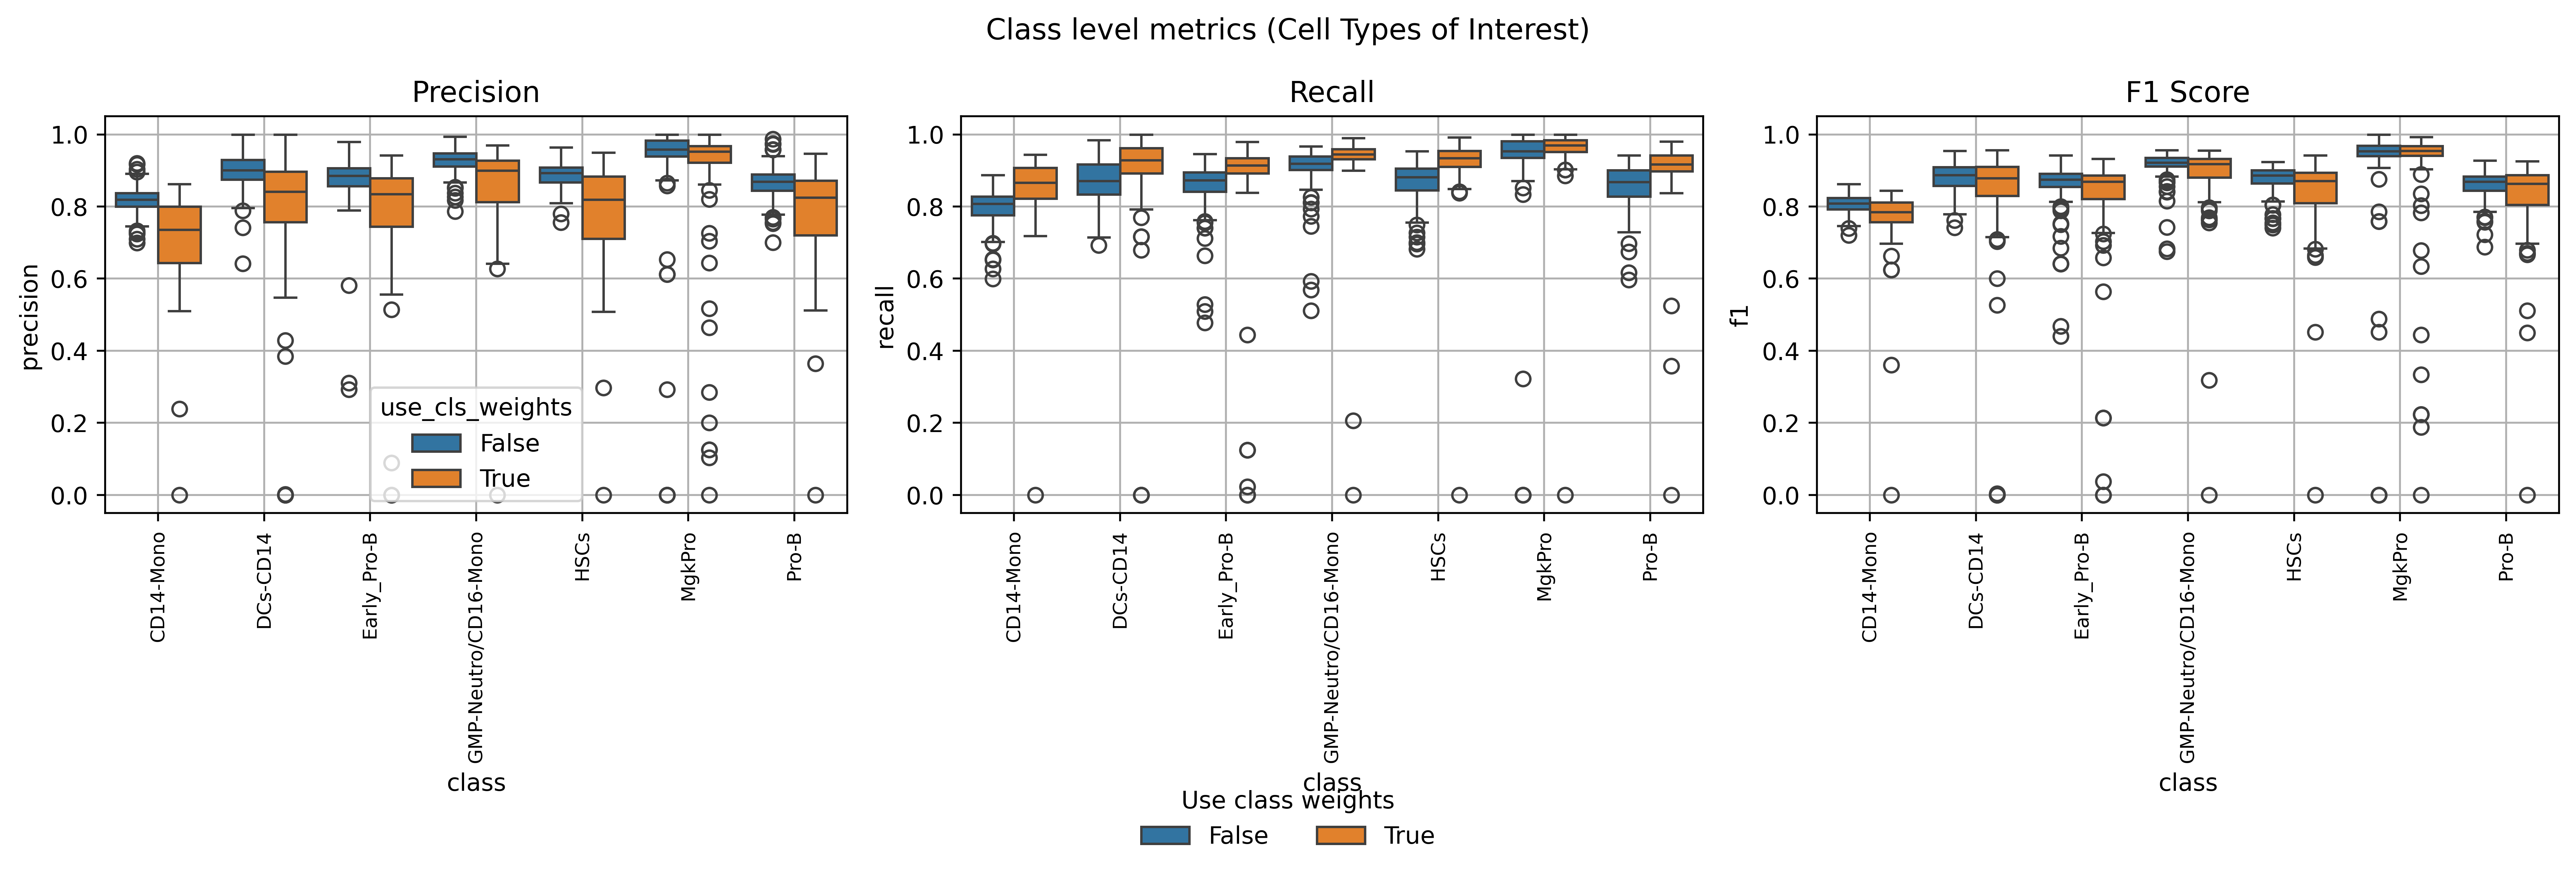

In [ ]:
cell_types_of_interest_eval_results_df = eval_results_df[
    eval_results_df["class"].map(lambda e: e in CELL_TYPES_OF_INTEREST)
]

fig, ax = plt.subplots(1, 3, figsize=(15, 5), dpi=500)
fig.suptitle("Class level metrics (Cell Types of Interest)")

sns.boxplot(
    data=cell_types_of_interest_eval_results_df,
    y="precision", x="class", hue="use_cls_weights",
    ax=ax[0], dodge=True
)
ax[0].tick_params(axis="x", rotation=90, labelsize=8)
ax[0].grid(True)
ax[0].set_title("Precision")

sns.boxplot(
    data=cell_types_of_interest_eval_results_df,
    y="recall", x="class", hue="use_cls_weights",
    ax=ax[1], dodge=True
)
ax[1].tick_params(axis="x", rotation=90, labelsize=8)
ax[1].grid(True)
ax[1].set_title("Recall")

sns.boxplot(
    data=cell_types_of_interest_eval_results_df,
    y="f1", x="class", hue="use_cls_weights",
    ax=ax[2], dodge=True
)
ax[2].tick_params(axis="x", rotation=90, labelsize=8)
ax[2].grid(True)
ax[2].set_title("F1 Score")

# Remove duplicate legends from second and third axes
for a in ax[1:]:
    a.get_legend().remove()

# Move and centralize one shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=2,
    title="Use class weights",
    frameon=False
)

fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.show()


### Plot Confusion Matrix of best model for each split.

In [ ]:
ood2bestmodel = {}
criterion = "f1"
global_eval_results_df = eval_results_df[eval_results_df["class"] == "GLOBAL"]
for group_id, group_idxs in global_eval_results_df.groupby(by=["seed", "split"]).groups.items():
    group_df = global_eval_results_df.loc[group_idxs]
    best_idx = group_df[criterion].argmax()
    best_model = group_df.iloc[best_idx]["model"]


northern-blaze-128
